In [8]:
## Proyecto Sprint 6 - Análisis de videojuegos
'El objetivo de este proyecto es identificar patrones que determinen el éxito de un videojuego, con el fin de planificar campañas publicitarias para el año 2017.Se analizarán datos históricos de ventas, plataformas, géneros y reseñas de usuarios y críticos.'

'El objetivo de este proyecto es identificar patrones que determinen el éxito de un videojuego, con el fin de planificar campañas publicitarias para el año 2017.Se analizarán datos históricos de ventas, plataformas, géneros y reseñas de usuarios y críticos.'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from pathlib import Path

for p in Path('.').rglob('*.csv'):
    print(p)

1.csv
megaline_messages.csv
vehicles_us.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\philox-testset-1.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\philox-testset-2.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\sfc64-testset-1.csv
Wallpaper Engine\dlc\pymidas\Lib\site-packages\numpy\random\tests\data\sfc64-testset-2.csv
Wallpaper Engine\dlc\pymidas\Lib

In [17]:
import pandas as pd
import os

print(os.getcwd())
print(os.path.exists('games.csv'))

df = pd.read_csv('games.csv')
print(df.head())

c:\Users\rodry\Downloads
True
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [ ]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
## Exploración inicial

#El dataset contiene 16,715 registros y 11 columnas.

#Se identificaron valores ausentes en varias columnas, especialmente en:
#- critic_score
#- user_score
#- rating
#- year_of_release

#La columna user_score está en formato texto debido a valores como "TBD".

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

df['user_score'] = df['user_score'].replace(['TBD', 'tbd'], np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [ ]:
### Conversión de datos

#Se convirtieron las columnas a formatos numéricos para permitir análisis.
#Los valores "TBD" en user_score fueron reemplazados por NaN, ya que representan datos no disponibles.

In [ ]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [ ]:
df = df.dropna(subset=['year_of_release'])

In [ ]:
#Se eliminaron los registros sin año de lanzamiento, ya que esta variable es clave para el análisis.

In [ ]:
df['total_sales'] = (
    df['na_sales'] + 
    df['eu_sales'] + 
    df['jp_sales'] + 
    df['other_sales']
)

In [ ]:
df['year_of_release'].value_counts().sort_index()

1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      62
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: year_of_release, dtype: int64

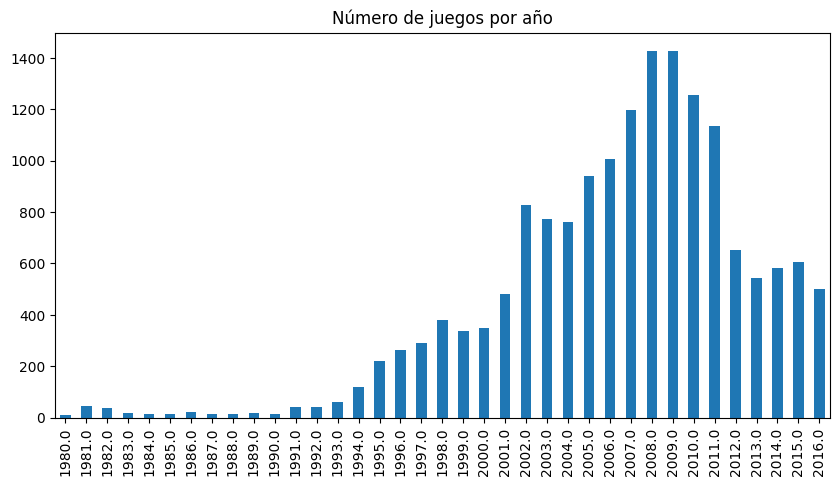

In [ ]:
df['year_of_release'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title('Número de juegos por año')
plt.show()

In [ ]:
# Distribución de juegos por año

#Se observa un crecimiento progresivo en el número de videojuegos lanzados desde la década de 1980, con un aumento significativo a partir de los años 2000.

#El número de lanzamientos alcanza su punto máximo entre 2008 y 2009, con más de 1400 juegos por año, lo que indica un periodo de alta actividad en la industria.

#A partir de 2010, se observa una disminución en el número de lanzamientos, lo que puede estar relacionado con cambios en el mercado, consolidación de plataformas o una mayor concentración en juegos de mayor calidad.

#También es posible que los datos más recientes (especialmente 2016) estén incompletos, lo que contribuye a la aparente disminución.

In [ ]:
df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

In [ ]:
# Ventas totales por plataforma

#Se observa que las plataformas con mayores ventas globales son PS2, Xbox 360 y PS3, lo que indica su gran popularidad y dominio del mercado durante sus respectivos ciclos de vida.

#También destacan plataformas como Wii y DS, que lograron altos niveles de ventas, posiblemente debido a su enfoque innovador y accesibilidad para un público más amplio.

#Por otro lado, plataformas más recientes como PS4 y Xbox One presentan menores ventas acumuladas, lo cual es esperable dado que han estado menos tiempo en el mercado en comparación con las plataformas más antiguas.

#Asimismo, se identifican múltiples plataformas con ventas muy bajas, lo que refleja que no todas logran consolidarse en la industria.

#En general, estos resultados evidencian que el éxito de una plataforma está altamente relacionado con su tiempo en el mercado, adopción por los usuarios y catálogo de juegos disponible.

In [ ]:
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)
top_platforms

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

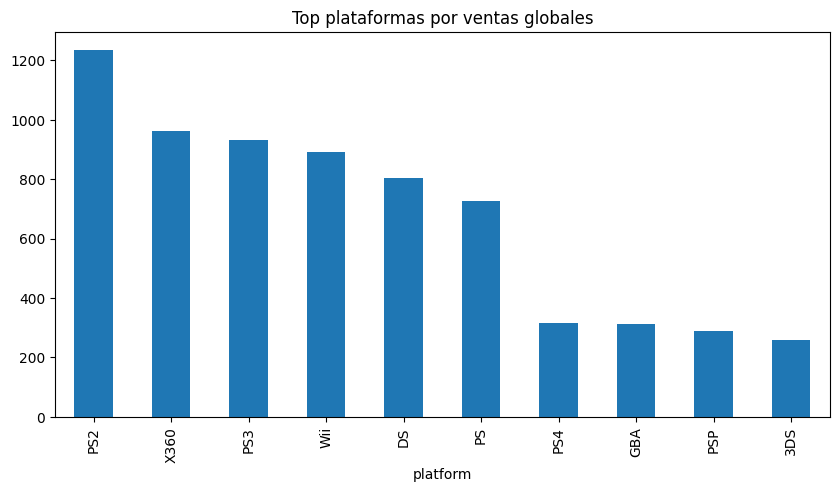

In [ ]:
top_platforms.plot(kind='bar', figsize=(10,5))
plt.title('Top plataformas por ventas globales')
plt.show()

In [ ]:
#Las plataformas con mayores ventas incluyen consolas populares como PlayStation y Xbox.

#Esto refleja la dominancia de estas plataformas en el mercado global de videojuegos.

In [ ]:
platform_year = df.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

platform_year

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980.0,11.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981.0,35.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982.0,28.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983.0,5.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984.0,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985.0,0.45,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986.0,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987.0,1.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988.0,0.74,NaN,NaN,NaN,NaN,1.43,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


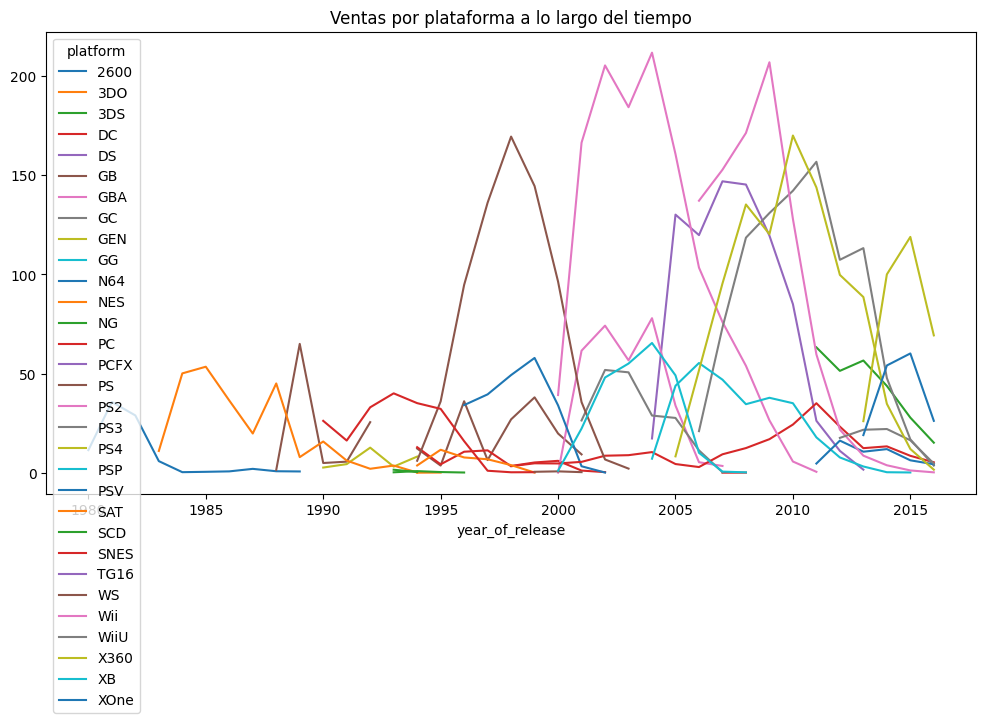

In [ ]:
platform_year.plot(figsize=(12,6))
plt.title('Ventas por plataforma a lo largo del tiempo')
plt.show()

In [ ]:
#Evolución de plataformas

#Se observa que las plataformas tienen ciclos de vida definidos.

#Algunas plataformas alcanzan un pico de popularidad y luego disminuyen hasta desaparecer, mientras que nuevas plataformas emergen y capturan el mercado.

#En general, el ciclo de vida de una plataforma parece durar entre 5 y 10 años.

In [ ]:
df_recent = df[df['year_of_release'] >= 2013]

In [ ]:
# Selección de datos relevantes

#Se seleccionaron los datos a partir de 2013, ya que reflejan mejor las tendencias actuales del mercado y son más útiles para predecir el comportamiento en 2017.

In [ ]:
sns.boxplot(data=df_recent, x='platform', y='total_sales', showfliers=False)
plt.xticks(rotation=45)
plt.title('Distribución de ventas por plataforma')
plt.show()

NameError: name 'sns' is not defined

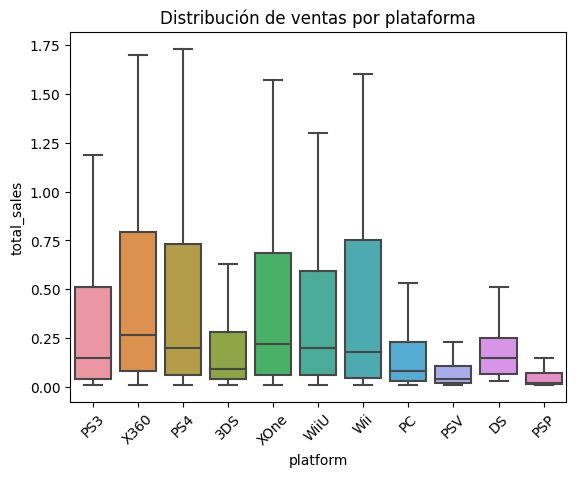

In [ ]:
sns.boxplot(data=df_recent, x='platform', y='total_sales', showfliers = False)
plt.xticks(rotation=45)
plt.title('Distribución de ventas por plataforma')
plt.show()

In [ ]:
print(f"Desviación estándar de ventas: {df_recent['total_sales'].std():.2f}")
print(f"Varianza de ventas: {df_recent['total_sales'].var():.2f}")

Desviación estándar de ventas: 1.24
Varianza de ventas: 1.53


In [ ]:
## Análisis de dispersión de ventas

#La desviación estándar muestra que existe una alta variabilidad en las ventas de los videojuegos, lo que indica que el desempeño comercial varía significativamente entre títulos.

#La varianza refuerza esta observación, evidenciando que las ventas no están distribuidas de manera uniforme.

#Esto coincide con el análisis del diagrama de caja, donde se observaron múltiples valores atípicos, lo que sugiere que unos pocos juegos generan la mayor parte de los ingresos.

In [ ]:
## Distribución de ventas por plataforma

#El diagrama de caja muestra una alta variabilidad en las ventas de videojuegos entre diferentes plataformas.

#Se observa que la mayoría de los juegos tienen ventas relativamente bajas, mientras que existen valores atípicos (outliers) que alcanzan ventas significativamente altas. Esto indica que el mercado está dominado por unos pocos juegos muy exitosos.

#Las medianas de ventas entre plataformas no presentan diferencias extremadamente marcadas, lo que sugiere que el rendimiento típico de los juegos es similar en muchos casos.

#Sin embargo, la presencia de valores extremos en algunas plataformas indica que ciertas consolas tienen mayor probabilidad de albergar títulos altamente exitosos.

#En general, la distribución asimétrica sugiere que el éxito en ventas no es la norma, sino la excepción, y depende de múltiples factores más allá de la plataforma.

In [ ]:
df_ps4 = df_recent[df_recent['platform'] == 'PS4']

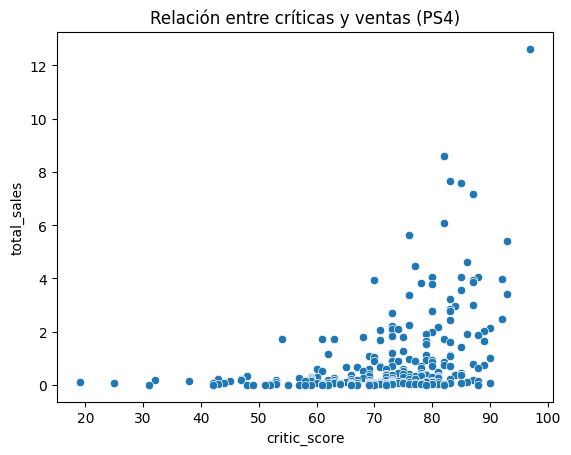

In [ ]:
sns.scatterplot(data=df_ps4, x='critic_score', y='total_sales')
plt.title('Relación entre críticas y ventas (PS4)')
plt.show()

In [ ]:
df_ps4[['critic_score', 'total_sales']].corr()

,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


In [ ]:
print(f"Correlación PS4: {df_ps4[['critic_score', 'total_sales']].corr().iloc[0,1]:.3f}")

Correlación PS4: 0.407


In [ ]:
#La correlación obtenida es aproximadamente 0.41, lo que indica una relación positiva moderada entre las reseñas de críticos y las ventas.

#Esto significa que, aunque mejores calificaciones tienden a asociarse con mayores ventas, no son el único factor determinante.

In [ ]:
# Relación entre reseñas de críticos y ventas

#Se observa una correlación positiva moderada (≈ 0.41) entre las calificaciones de los críticos y las ventas totales.

#Esto sugiere que los juegos con mejores reseñas tienden a generar mayores ventas, aunque la relación no es lo suficientemente fuerte como para considerarla determinante.

#Por lo tanto, si bien las críticas influyen en el éxito comercial de un videojuego, existen otros factores importantes, como el marketing, la popularidad de la franquicia o la plataforma.

#En conclusión, las reseñas de críticos son un factor relevante, pero no el único que determina el éxito de un juego.

In [ ]:
df_recent.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64

In [ ]:
## Análisis por género

#Se observa que el género Shooter presenta las mayores ventas promedio, superando significativamente al resto, lo que indica una alta rentabilidad y popularidad entre los jugadores.

#Otros géneros como Sports, Platform y Role-Playing también muestran un desempeño sólido, lo que sugiere que mantienen una demanda constante en el mercado.

#En contraste, géneros como Puzzle, Strategy y Adventure presentan las ventas promedio más bajas, lo que indica un menor impacto comercial en comparación con otros géneros.

#En general, los géneros con mayor acción y dinamismo tienden a generar más ingresos, mientras que los géneros más especializados o narrativos suelen tener un alcance más limitado.

#Esto sugiere que, para maximizar el éxito comercial, es recomendable enfocarse en géneros con alta demanda como Shooter y Sports, especialmente en plataformas populares.

In [ ]:
df_recent.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

In [ ]:
# Plataformas principales en Norteamérica (NA)

#Las plataformas con mayores ventas en Norteamérica son PS4, Xbox One y Xbox 360, seguidas por PS3 y 3DS.

#Se observa una fuerte presencia de consolas de sobremesa modernas como PS4 y Xbox One, lo que indica una preferencia por plataformas de alto rendimiento en esta región.

#Asimismo, la presencia de Xbox (XOne y X360) es significativa, lo que refleja la popularidad de esta marca en el mercado norteamericano en comparación con otras regiones.

#En contraste, las consolas portátiles como 3DS tienen menor participación, lo que sugiere que el mercado de Norteamérica está más orientado hacia experiencias de juego en consola de hogar.

#En general, Norteamérica muestra una clara preferencia por consolas modernas y de alto rendimiento.

In [ ]:
df_recent.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

In [ ]:
## Plataformas principales en Europa (EU)

#En Europa, la plataforma con mayores ventas es PS4, seguida por PS3, Xbox One, Xbox 360 y 3DS.

#Se observa un claro dominio de las consolas PlayStation, particularmente PS4 y PS3, lo que indica una mayor preferencia por esta marca en el mercado europeo.

#Aunque Xbox también tiene presencia, su participación es menor en comparación con Norteamérica, lo que sugiere diferencias regionales en la preferencia de plataformas.

#Al igual que en Norteamérica, las consolas de sobremesa dominan el mercado, mientras que las plataformas portátiles como 3DS tienen una menor participación.

#En general, Europa muestra una fuerte inclinación hacia el ecosistema PlayStation, destacando diferencias importantes respecto a otras regiones.

In [ ]:
df_recent.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

In [ ]:
## Plataformas principales en Japón (JP)

#En Japón, la plataforma con mayores ventas es 3DS, seguida por PS3, PS Vita, PS4 y WiiU.

#A diferencia de Norteamérica y Europa, se observa una clara preferencia por consolas portátiles, especialmente 3DS, que domina ampliamente el mercado japonés.

#Además, plataformas como PS Vita también tienen una presencia relevante, lo que refuerza la importancia del juego portátil en esta región.

#Las consolas de sobremesa como PS4 y Xbox tienen menor participación en comparación con otras regiones, lo que evidencia diferencias significativas en los hábitos de consumo.

#En general, el mercado japonés muestra una fuerte inclinación hacia plataformas portátiles y experiencias de juego más accesibles, en contraste con el enfoque en consolas de alto rendimiento observado en Occidente.

In [ ]:
df_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

In [ ]:
## Géneros principales en Norteamérica (NA)

#En Norteamérica (principalmente Estados Unidos), los géneros con mayores ventas son Action y Shooter, seguidos por Sports, Role-Playing y Misc.

#Se observa una clara preferencia por juegos de acción y alta intensidad, lo que sugiere que los usuarios de esta región valoran experiencias dinámicas, competitivas y con alto nivel de interacción.

#El género Sports también tiene una participación importante, lo que refleja el interés por simulaciones deportivas en este mercado.

#Por otro lado, géneros como Role-Playing mantienen una presencia relevante, aunque menor en comparación con Acción y Shooter.

#En general, el mercado norteamericano está fuertemente orientado hacia géneros de acción y entretenimiento rápido, lo que puede influir en las estrategias de desarrollo y marketing.

In [ ]:
df_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

In [ ]:
## Géneros principales en Europa (EU)

#En Europa, los géneros con mayores ventas son Action y Shooter, seguidos por Sports, Role-Playing y Racing.

#Se observa un patrón similar al de Norteamérica, con una fuerte preferencia por juegos de acción y dinamismo.

#El género Sports también tiene una participación relevante, lo que indica un interés constante en juegos deportivos dentro del mercado europeo.

#En general, Europa comparte muchas similitudes con Norteamérica en cuanto a preferencias de género, aunque con ligeras variaciones en la importancia relativa de cada uno.

In [ ]:
df_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64

In [ ]:
## Géneros principales en Japón (JP)

#En Japón, el género dominante es Role-Playing, seguido por Action, Misc, Fighting y Shooter.

#A diferencia de Norteamérica y Europa, donde predominan los géneros de acción y disparos, Japón muestra una clara preferencia por juegos de rol.

#Esto sugiere una inclinación hacia experiencias más narrativas y profundas, características típicas de los RPG.

#Además, la presencia de géneros como Fighting refleja diferencias culturales en las preferencias de entretenimiento.

In [ ]:
## Comparación de géneros por región

#Se observan diferencias claras entre las regiones analizadas.

#Norteamérica y Europa presentan patrones muy similares, con una fuerte preferencia por géneros como Action, Shooter y Sports.

#En contraste, Japón muestra un comportamiento distinto, donde el género Role-Playing domina el mercado.

#Estas diferencias reflejan variaciones culturales en los gustos de los jugadores y destacan la importancia de adaptar las estrategias de desarrollo y marketing según la región.

#En conclusión, mientras que los mercados occidentales prefieren experiencias dinámicas y competitivas, Japón se inclina más hacia juegos con narrativa y progresión.

In [ ]:
df_recent.groupby('rating')['na_sales'].sum().sort_values(ascending=False)

rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64

In [ ]:
## Impacto de la clasificación ESRB en Norteamérica (NA)

#En Norteamérica (principalmente Estados Unidos), los juegos con clasificación "M" (Mature) presentan las mayores ventas, seguidos por las clasificaciones "E" (Everyone) y "E10+".

#Esto indica que una gran parte del mercado está compuesta por jugadores adultos, lo que favorece el éxito de juegos con contenido más maduro.

#Las clasificaciones "T" (Teen) también tienen una participación relevante, aunque menor en comparación con las anteriores.

#En general, la clasificación ESRB influye en las ventas, ya que define el público objetivo de los juegos, siendo los títulos dirigidos a audiencias adultas los más rentables en esta región.

In [ ]:
df_recent.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)

rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64

In [ ]:
## Impacto de la clasificación ESRB en Europa (EU)

#En Europa, los juegos con clasificación "M" (Mature) también presentan las mayores ventas, seguidos por "E" (Everyone), "E10+" y "T" (Teen).

#Este patrón es similar al observado en Norteamérica, lo que sugiere que los juegos dirigidos a audiencias adultas tienen una alta demanda en los mercados occidentales.

#Las clasificaciones "E" y "E10+" también mantienen una participación significativa, lo que indica que existe un mercado relevante para juegos dirigidos a públicos más amplios.

#En general, la clasificación ESRB influye en las ventas en Europa de manera similar a Norteamérica, con una clara preferencia por títulos orientados a jugadores adultos.

In [ ]:
df_recent.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64

In [ ]:
## Impacto de la clasificación ESRB en Japón (JP)

#En Japón, los juegos con clasificación "T" (Teen) presentan las mayores ventas, seguidos por "E" (Everyone) y "M" (Mature).

#A diferencia de Norteamérica y Europa, donde dominan los juegos con clasificación "M", en Japón se observa una preferencia por contenido más moderado y accesible.

#Esto sugiere que el público japonés tiende a consumir juegos con menor contenido violento o explícito, en comparación con los mercados occidentales.

#Las clasificaciones "E10+" tienen menor participación, lo que indica una menor demanda relativa en este segmento.

#En general, la influencia de la clasificación ESRB varía significativamente por región, reflejando diferencias culturales en los hábitos de consumo.

In [ ]:
# Comparación de la clasificación ESRB por región

#Se observan diferencias claras en el impacto de la clasificación ESRB entre regiones.

#En Norteamérica y Europa, los juegos con clasificación "M" (Mature) dominan las ventas, lo que indica una fuerte presencia de jugadores adultos y una preferencia por contenido más intenso.

#En contraste, Japón muestra una mayor preferencia por juegos con clasificación "T" (Teen) y "E" (Everyone), lo que sugiere un enfoque hacia contenido más accesible y menos explícito.

#Estas diferencias reflejan variaciones culturales en los gustos de los jugadores y resaltan la importancia de adaptar tanto el desarrollo de juegos como las estrategias de marketing a cada región.

#En conclusión, la clasificación ESRB es un factor relevante en las ventas, pero su impacto varía significativamente dependiendo del mercado.

In [ ]:
from scipy import stats

In [ ]:
xbox = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
pc = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()

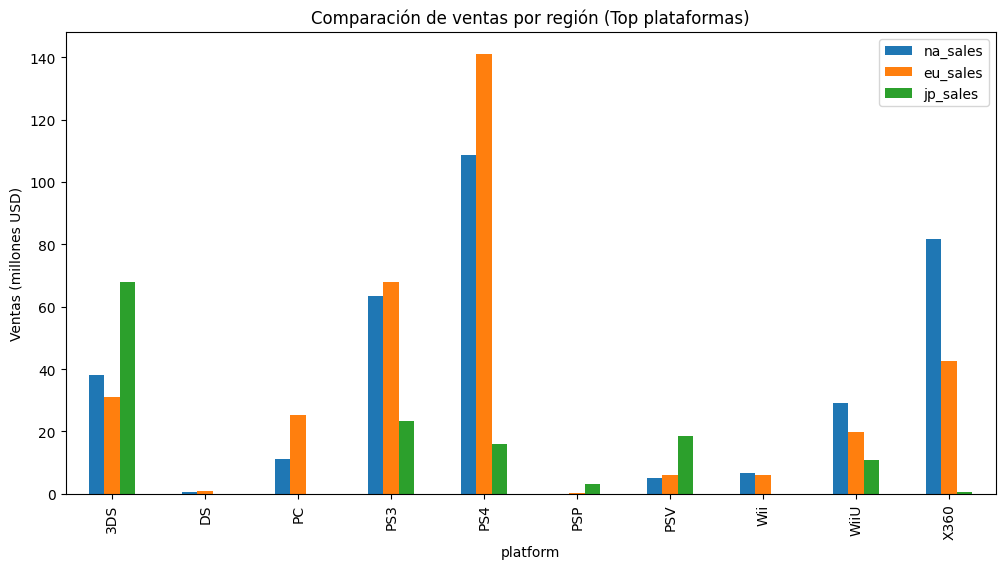

In [ ]:
region_sales = df_recent.groupby('platform')[['na_sales','eu_sales','jp_sales']].sum()

region_sales.head(10).plot(kind='bar', figsize=(12,6))
plt.title('Comparación de ventas por región (Top plataformas)')
plt.ylabel('Ventas (millones USD)')
plt.show()

In [ ]:
## Comparación visual entre regiones

#Se observa cómo varían las ventas de las principales plataformas entre Norteamérica, Europa y Japón.

#Las diferencias evidencian patrones regionales claros, donde Norteamérica y Europa presentan comportamientos similares, mientras que Japón muestra preferencias muy distintas.

In [ ]:
## Prueba de hipótesis 1

#Hipótesis nula (H0): Las calificaciones promedio de usuarios para Xbox One y PC son iguales.

#Hipótesis alternativa (H1): Las calificaciones promedio son diferentes.

#Se utilizó la prueba t de Student para comparar las medias de dos muestras independientes.

#Nivel de significancia: 0.05

In [ ]:
alpha = 0.05

results = stats.ttest_ind(xbox, pc)

print(results.pvalue)

0.14012658403611647


In [ ]:
### Resultados de la prueba

#El valor p obtenido es 0.1401, el cual es mayor que el nivel de significancia establecido (α = 0.05).

#Por lo tanto, no se rechaza la hipótesis nula.

#Esto significa que no hay evidencia estadísticamente significativa para afirmar que las calificaciones promedio de los usuarios para Xbox One y PC sean diferentes.

#En conclusión, las calificaciones de los usuarios para ambas plataformas pueden considerarse estadísticamente similares.

In [ ]:
action = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
sports = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()

In [ ]:
## Prueba de hipótesis 2

#Hipótesis nula (H0): Las calificaciones promedio de los usuarios para los géneros Action y Sports son iguales.

#Hipótesis alternativa (H1): Las calificaciones promedio son diferentes.

#Se utilizó la prueba t de Student para comparar las medias de dos muestras independientes.

#Nivel de significancia: 0.05

In [ ]:
results = stats.ttest_ind(action, sports)

print(results.pvalue)

1.0517832389140023e-27


In [ ]:
### Resultados de la prueba

#El valor p obtenido es extremadamente pequeño (≈ 0), lo que es significativamente menor que el nivel de significancia (α = 0.05).

#Por lo tanto, se rechaza la hipótesis nula.

#Esto indica que existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para los géneros Action y Sports.

#En conclusión, los usuarios califican de manera diferente estos dos géneros, lo que sugiere que el tipo de juego influye en la percepción de calidad por parte de los jugadores.

In [ ]:
## Conclusión general

#A lo largo del análisis se identificaron varios factores clave que influyen en el éxito de un videojuego.

#En primer lugar, las plataformas tienen ciclos de vida definidos, donde alcanzan un pico de popularidad y posteriormente disminuyen. Las plataformas más recientes como PS4 y Xbox One muestran potencial de crecimiento y son relevantes para futuras estrategias.

#En cuanto a los géneros, se observó que Shooter y Action generan las mayores ventas, especialmente en mercados occidentales, mientras que en Japón predominan los juegos de tipo Role-Playing.

#El análisis por región evidenció diferencias significativas en las preferencias de los usuarios. Norteamérica y Europa comparten patrones similares, con preferencia por consolas de alto rendimiento y juegos de acción, mientras que Japón muestra una inclinación hacia plataformas portátiles y géneros más narrativos.

#Las reseñas de críticos presentan una correlación positiva moderada con las ventas, lo que indica que influyen en el éxito comercial, aunque no son el único factor determinante.

#Finalmente, las pruebas de hipótesis mostraron que no existen diferencias significativas en las calificaciones entre plataformas Xbox One y PC, pero sí entre los géneros Action y Sports.

#En conclusión, para maximizar el éxito de un videojuego en 2017, se recomienda enfocarse en plataformas modernas, géneros populares según la región y considerar las diferencias culturales en las preferencias de los usuarios.

### Recomendaciones para 2017

#- Enfocar el desarrollo y marketing en plataformas modernas como PS4 y Xbox One.
#- Priorizar géneros de alto rendimiento como Shooter y Action en mercados occidentales.
#- Adaptar la estrategia para Japón, enfocándose en géneros como Role-Playing y plataformas portátiles.
#- Considerar la influencia de las reseñas de críticos como un factor adicional, pero no determinante en el éxito comercial.